In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

from rural_stroke_assist.config import (
    FACE_TRIAL_003_PREDICTIONS_PATH,
    FACE_FALSE_POSITIVES_PATH,
    FACE_FALSE_NEGATIVES_PATH,
    FACE_LOW_CONFIDENCE_CORRECT_PATH,
    FACE_HIGH_CONFIDENCE_ERRORS_PATH,
)

from rural_stroke_assist.modeling.error_analysis import (
    extract_false_positives,
    extract_false_negatives,
    extract_low_confidence_correct,
    extract_high_confidence_errors,
)

In [2]:
predictions_df = pd.read_csv(
    FACE_TRIAL_003_PREDICTIONS_PATH
)

predictions_df.head()

,path,file_name,class_label,extension,readable,width,height,file_hash,is_clean,split,true_label_encoded,stroke_probability,predicted_label_encoded,true_label,predicted_label,is_correct
0,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0024.jpg,NonStroke,.jpg,True,379,379,b2a1a613cdb309d96a998ed46adea5fe182aa661a40c88...,True,test,0,0.163974,0,NonStroke,NonStroke,True
1,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0030.jpg,NonStroke,.jpg,True,342,382,bac0af9d5eef5722d3b989d1e29677f6d4b479bda29748...,True,test,0,0.556995,1,NonStroke,Stroke,False
2,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0034.jpg,NonStroke,.jpg,True,299,169,e55c08bb962face7207d8c1275f0f6ddefd8aa7b6b8ff9...,True,test,0,0.010577,0,NonStroke,NonStroke,True
3,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0044.jpg,NonStroke,.jpg,True,531,573,a63c03d2bb88d41be3b94d3d5bc904e6cc11a222e35354...,True,test,0,0.020172,0,NonStroke,NonStroke,True
4,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,img_0061.jpg,NonStroke,.jpg,True,123,129,b3406760ebe5924fd6e5d9b744bf8676ff2df41ddf3162...,True,test,0,0.697004,1,NonStroke,Stroke,False


In [3]:
false_positives = extract_false_positives(
    predictions_df
)

false_negatives = extract_false_negatives(
    predictions_df
)

low_confidence_correct = (
    extract_low_confidence_correct(
        predictions_df
    )
)

high_confidence_errors = (
    extract_high_confidence_errors(
        predictions_df
    )
)

In [4]:
print(
    "False Positives:",
    len(false_positives)
)

print(
    "False Negatives:",
    len(false_negatives)
)

print(
    "Low Confidence Correct:",
    len(low_confidence_correct)
)

print(
    "High Confidence Errors:",
    len(high_confidence_errors)
)

False Positives: 12
False Negatives: 11
Low Confidence Correct: 50
High Confidence Errors: 23


In [5]:
FACE_FALSE_POSITIVES_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

false_positives.to_csv(
    FACE_FALSE_POSITIVES_PATH,
    index=False,
)

false_negatives.to_csv(
    FACE_FALSE_NEGATIVES_PATH,
    index=False,
)

low_confidence_correct.to_csv(
    FACE_LOW_CONFIDENCE_CORRECT_PATH,
    index=False,
)

high_confidence_errors.to_csv(
    FACE_HIGH_CONFIDENCE_ERRORS_PATH,
    index=False,
)

In [6]:
false_negatives[
    [
        "path",
        "stroke_probability",
        "true_label",
        "predicted_label",
    ]
].sort_values(
    "stroke_probability"
).head(20)

,path,stroke_probability,true_label,predicted_label
262,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.222733,Stroke,NonStroke
294,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.223977,Stroke,NonStroke
214,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.318294,Stroke,NonStroke
245,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.335943,Stroke,NonStroke
264,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.365547,Stroke,NonStroke
286,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.386763,Stroke,NonStroke
233,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.398830,Stroke,NonStroke
291,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.415249,Stroke,NonStroke
227,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.419423,Stroke,NonStroke
273,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.448233,Stroke,NonStroke


In [7]:
high_confidence_errors[
    [
        "path",
        "stroke_probability",
        "true_label",
        "predicted_label",
        "confidence",
    ]
].head(20)

,path,stroke_probability,true_label,predicted_label,confidence
262,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.222733,Stroke,NonStroke,0.277267
294,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.223977,Stroke,NonStroke,0.276023
30,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.724541,NonStroke,Stroke,0.224541
4,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.697004,NonStroke,Stroke,0.197004
214,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.318294,Stroke,NonStroke,0.181706
245,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.335943,Stroke,NonStroke,0.164057
47,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.635783,NonStroke,Stroke,0.135783
264,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.365547,Stroke,NonStroke,0.134453
286,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.386763,Stroke,NonStroke,0.113237
138,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.608209,NonStroke,Stroke,0.108209


path                       C:\Users\Asus\Downloads\Uni_work\Grad-Project\...
file_name                                                       img_2825.jpg
class_label                                                           Stroke
extension                                                               .jpg
readable                                                                True
width                                                                    194
height                                                                   259
file_hash                  4b11219d0472811dbafddb64904853de94fbe40b3d1c8a...
is_clean                                                                True
split                                                                   test
true_label_encoded                                                         1
stroke_probability                                                  0.498619
predicted_label_encoded                                                    0

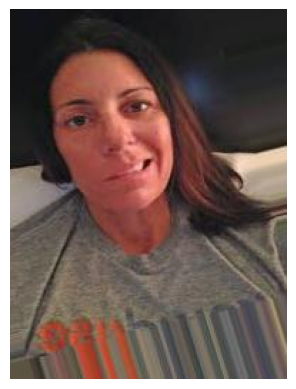

In [10]:
sample = false_negatives.iloc[10]

image = Image.open(
    sample["path"]
)

plt.imshow(image)
plt.axis("off")

print(sample)

In [11]:
false_positives[
    [
        "path",
        "stroke_probability",
        "true_label",
        "predicted_label",
    ]
].sort_values(
    "stroke_probability"
).head(20)

,path,stroke_probability,true_label,predicted_label
110,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.501065,NonStroke,Stroke
55,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.529234,NonStroke,Stroke
159,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.530691,NonStroke,Stroke
1,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.556995,NonStroke,Stroke
53,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.565732,NonStroke,Stroke
9,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.566258,NonStroke,Stroke
204,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.577617,NonStroke,Stroke
124,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.597837,NonStroke,Stroke
138,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.608209,NonStroke,Stroke
47,C:\Users\Asus\Downloads\Uni_work\Grad-Project\...,0.635783,NonStroke,Stroke


path                       C:\Users\Asus\Downloads\Uni_work\Grad-Project\...
file_name                                                       img_3564.jpg
class_label                                                        NonStroke
extension                                                               .jpg
readable                                                                True
width                                                                    441
height                                                                   600
file_hash                  540f764ff39c67eed5e9118ec99e5e9844565b69814306...
is_clean                                                                True
split                                                                   test
true_label_encoded                                                         0
stroke_probability                                                  0.577617
predicted_label_encoded                                                    1

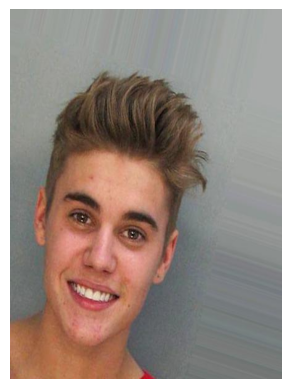

In [25]:
sample = false_positives.iloc[11]

image = Image.open(
    sample["path"]
)

plt.imshow(image)
plt.axis("off")

print(sample)